In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as linalg

# Exercise 10-1
- LU decomposition is computationally expensive
- Time how long it takes to calculate for a 100x100 matrix

In [2]:
%%timeit
A = np.random.default_rng().random((100,100))
_, L, U = linalg.lu(A)

114 μs ± 3.17 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


# Exercise 10-2
- Use matrix multiplication method to make a 6x8 rank-3 matrix
- Take it's LU decomposition
- Show the three matrices with their ranks in the file
- Notice the ranks of the three matrices and that L has all 1s on the diagonal

In [3]:
def matrix_of_rank(M: int, N: int, rank: int) -> np.ndarray:
    A = np.random.randn(M, rank) @ np.random.randn(rank, N)
    return A

In [4]:
A = matrix_of_rank(6,8,3)
A

array([[ 2.34997701, -0.70362351, -0.36522477,  0.44650515, -1.62643121,
        -1.41592301, -0.46660451,  2.91692758],
       [ 0.43083086, -0.70999077,  0.00982034,  0.4182528 , -0.27807723,
        -0.28852186,  0.23163594,  0.89028611],
       [-0.07298287,  1.80365422, -0.28512611, -1.08903765, -0.18867321,
        -1.32400984, -0.02263784,  0.63401235],
       [ 0.43971465,  3.39348189, -0.63706672, -2.03088049, -0.72570445,
        -2.54608299, -0.43391816,  1.44949795],
       [-1.18644963,  3.74600055, -0.39712636, -2.28384225,  0.31551171,
        -2.30251178,  0.43089444,  0.42216167],
       [ 1.84610802, -1.52695885, -0.18318222,  0.89699076, -1.31677237,
        -1.75803419,  0.54884224,  3.63164255]])

In [5]:
P, L, U = linalg.lu(A)

In [6]:
matrices = [
    ("A", A, np.linalg.matrix_rank(A)),
    ("L", L, np.linalg.matrix_rank(L)),
    ("U", U, np.linalg.matrix_rank(U)),
    ("LU = A", P @ L @ U, np.linalg.matrix_rank(L @ U)),
]

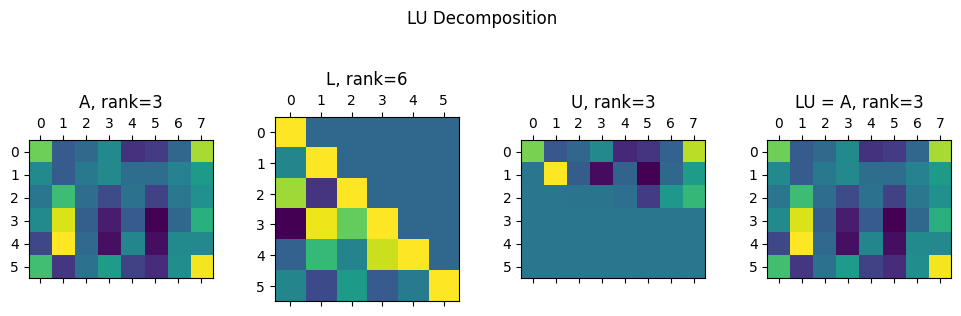

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=len(matrices), figsize=(10,4))
fig.suptitle("LU Decomposition")
fig.tight_layout()
for i, data in enumerate(matrices):
    name, matrix, rank = data
    axes[i].matshow(matrix)
    axes[i].set_title(f"{name}, rank={rank}")

- I added in the plot of $LU = A$ to show that the decomposition does describe the $A$ matrix
- It makes sense to me that $U$ can only have a rank equal to the rank of the matrix $A$ but why?

# Exercise 10-3
- One application of LU decomposition is calculating the determinant
- 2 properties of a determinant that are relevant
    - the determinant of a triangular matrix is the product of it's diagonals
    - the determinant of a product matrix equals the product of the determinants $det(AB) = det(A)det(B)$
- You can compute the determinant of a matrix $A$ by multiplying the determinants $det(L)det(U)$ together
- You can compute the determinant of both $L$ and $U$ simply by multiplying their diagonals together (since they're both diagonal)
- Because $L$ diagonals are all 1, $det(A) = det(U)$
- Try in python

In [9]:
A = np.random.default_rng().random((5, 5))
P, L, U = linalg.lu(A)

In [10]:
np.linalg.det(A), np.linalg.det(U)

(np.float64(-0.07512065875577101), np.float64(0.07512065875577101))

As observed the magnitude is off because as the author described he intentionally left out the P matrix. The determinant of P is 1 for an even number of row swaps and -1 for an odd number of row swaps

In [11]:
np.linalg.det(A), np.linalg.det(P), np.linalg.det(P) * np.linalg.det(U)

(np.float64(-0.07512065875577101),
 np.float64(-1.0),
 np.float64(-0.07512065875577101))

The P matrix having a determinant of +-1 makes sense given it is an identity matrix that has it's rows swapped. The determinant of I = 1.

# Exercise 10-4
- The formula for LU Decomposition results in the following equation to find $A^{-1}$
$$
A^{-1} = U^{-1} L^{-1} P
$$
- Implement the 3rd equation directly using the output of `scipy.linalg.lu` on a 4x4 matrix
- Is $A A^{-1} = I$?
- This can vary based on what was previously wrote about $P$. Thus change the code such that we get $I$

In [12]:
A = np.random.default_rng().random((4, 4))
P, L, U = linalg.lu(A)

In [13]:
A_inv1 = np.linalg.inv(U) @ np.linalg.inv(L) @ P

In [14]:
# this may or may not be an identity matrix
A_inv1 @ A

array([[ 1.00000000e+00,  9.71445147e-17,  1.35308431e-16,
         3.81639165e-16],
       [ 0.00000000e+00,  1.00000000e+00, -6.93889390e-18,
         4.16333634e-17],
       [-8.88178420e-16,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00, -6.66133815e-16, -2.22044605e-16,
         1.00000000e+00]])

In [15]:
# we need to use the transpose of P for it to consistently give us A^-1
A_inv2 = np.linalg.inv(U) @ np.linalg.inv(L) @ P.T
A_inv2 @ A

array([[ 1.00000000e+00,  9.71445147e-17,  1.35308431e-16,
         3.81639165e-16],
       [ 0.00000000e+00,  1.00000000e+00, -6.93889390e-18,
         4.16333634e-17],
       [-8.88178420e-16,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00, -6.66133815e-16, -2.22044605e-16,
         1.00000000e+00]])

# Exercise 10-5
- For matrix $A = PLU$, $A^T A$ can be computed as $U^T L^T L U$ without permutation matrices
- Why is this possible? Answer: P transpose times P will just give you the identity matrix

In [16]:
A = np.random.default_rng().random((5, 5))
P, L, U = linalg.lu(A)

In [17]:
U.T @ L.T @ L @ U

array([[2.12393683, 2.03062921, 1.61827762, 1.868909  , 1.69735421],
       [2.03062921, 2.42189766, 1.96666437, 2.02120671, 1.61660358],
       [1.61827762, 1.96666437, 2.27140206, 1.6649457 , 1.59578682],
       [1.868909  , 2.02120671, 1.6649457 , 1.77381147, 1.4544395 ],
       [1.69735421, 1.61660358, 1.59578682, 1.4544395 , 1.71208692]])

In [72]:
A.T @ A

array([[1.8922968 , 1.6419104 , 1.18290996, 1.59239578, 2.11915379],
       [1.6419104 , 2.99714918, 2.13522038, 1.5374902 , 2.33015558],
       [1.18290996, 2.13522038, 1.8120007 , 1.06035284, 1.75681905],
       [1.59239578, 1.5374902 , 1.06035284, 1.38428232, 1.82900626],
       [2.11915379, 2.33015558, 1.75681905, 1.82900626, 2.55996288]])